# 04 - Análise de Crescimento e Receita | Case Olist

Análise da trilha de Crescimento e Receita, a partir de `data/processado/`.
Cobre evolução temporal, distribuição geográfica, categorias, sellers,
recompra, e termina cruzando com a trilha de Logística (coluna `atrasado`),
para reforçar a pergunta norteadora do projeto.

Base: pedidos entre jan/2017 e ago/2018 (meses fora desse intervalo têm
volume quase nulo e são excluídos das séries temporais, conforme documentado
em `documentos/dicionario_de_dados.md`).

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

## 0. Carregando os dados

In [2]:
fato_pedidos = pd.read_csv("../data/processado/fato_pedidos.csv")
dim_clientes = pd.read_csv("../data/processado/dim_clientes.csv")
dim_produtos = pd.read_csv("../data/processado/dim_produtos.csv")

fato_pedidos["order_purchase_timestamp"] = pd.to_datetime(fato_pedidos["order_purchase_timestamp"])
fato_pedidos["ano_mes"] = fato_pedidos["order_purchase_timestamp"].dt.strftime("%Y-%m")

# Juntar categoria e estado direto na tabela fato, para não repetir merge em toda célula
fato = fato_pedidos.merge(dim_produtos[["product_id", "product_category_name_english"]], on="product_id", how="left")
fato = fato.merge(dim_clientes[["customer_id", "customer_state", "customer_unique_id"]], on="customer_id", how="left")

meses_validos = fato[(fato["ano_mes"] >= "2017-01") & (fato["ano_mes"] <= "2018-08")]
print("Linhas para análise:", len(meses_validos))

Linhas para análise: 112279


## 1. Evolução Temporal

In [3]:
receita_mensal = meses_validos.groupby("ano_mes")["price"].sum()
pedidos_mensal = meses_validos.groupby("ano_mes")["order_id"].nunique()
ticket_medio_mensal = receita_mensal / pedidos_mensal

print(pd.DataFrame({"receita": receita_mensal.round(0), "pedidos": pedidos_mensal, "ticket_medio": ticket_medio_mensal.round(2)}))

           receita  pedidos  ticket_medio
ano_mes                                  
2017-01   120313.0      789        152.49
2017-02   247303.0     1733        142.70
2017-03   374344.0     2641        141.74
2017-04   359927.0     2391        150.53
2017-05   506071.0     3660        138.27
2017-06   433039.0     3217        134.61
2017-07   498031.0     3969        125.48
2017-08   573972.0     4293        133.70
2017-09   624402.0     4243        147.16
2017-10   664219.0     4568        145.41
2017-11  1010271.0     7451        135.59
2017-12   743914.0     5624        132.27
2018-01   950030.0     7220        131.58
2018-02   844179.0     6694        126.11
2018-03   983213.0     7188        136.79
2018-04   996648.0     6934        143.73
2018-05   996518.0     6853        145.41
2018-06   865124.0     6160        140.44
2018-07   895507.0     6273        142.76
2018-08   854686.0     6452        132.47


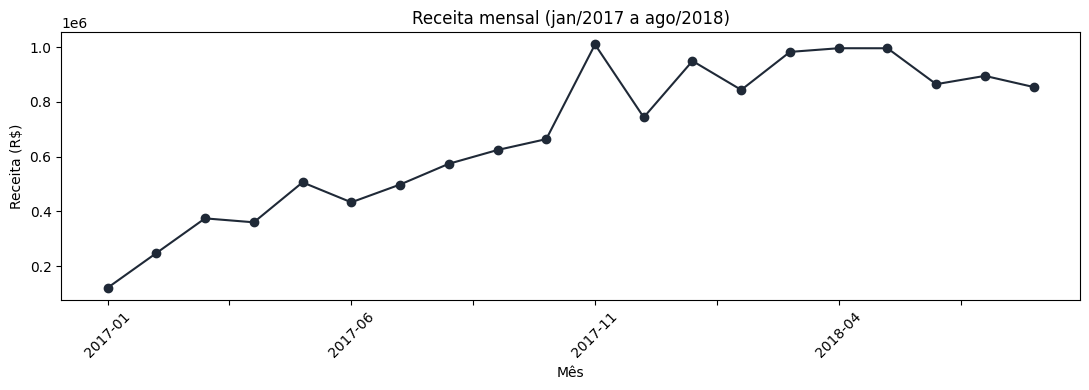

In [4]:
fig, ax = plt.subplots(figsize=(11, 4))
receita_mensal.plot(kind="line", marker="o", ax=ax, color="#1f2937")
ax.set_title("Receita mensal (jan/2017 a ago/2018)")
ax.set_ylabel("Receita (R$)")
ax.set_xlabel("Mês")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Taxa de crescimento mês a mês

In [5]:
crescimento_mom = receita_mensal.pct_change() * 100
print(crescimento_mom.round(1))
print("\nCrescimento médio mês a mês:", round(crescimento_mom.mean(), 1), "%")

ano_mes
2017-01      NaN
2017-02    105.5
2017-03     51.4
2017-04     -3.9
2017-05     40.6
2017-06    -14.4
2017-07     15.0
2017-08     15.2
2017-09      8.8
2017-10      6.4
2017-11     52.1
2017-12    -26.4
2018-01     27.7
2018-02    -11.1
2018-03     16.5
2018-04      1.4
2018-05     -0.0
2018-06    -13.2
2018-07      3.5
2018-08     -4.6
Name: price, dtype: float64

Crescimento médio mês a mês: 14.2 %


### Sazonalidade

Com pouco mais de um ano e meio de dados, não dá pra confirmar sazonalidade sólida (precisaria de vários anos), mas dá pra ver quais meses do calendário se destacam somando os dois anos disponíveis.

In [6]:
receita_por_mes_calendario = meses_validos.copy()
receita_por_mes_calendario["mes"] = receita_por_mes_calendario["order_purchase_timestamp"].dt.month
print(receita_por_mes_calendario.groupby("mes")["price"].sum().round(0))

mes
1     1070343.0
2     1091482.0
3     1357558.0
4     1356575.0
5     1502589.0
6     1298163.0
7     1393539.0
8     1428658.0
9      624402.0
10     664219.0
11    1010271.0
12     743914.0
Name: price, dtype: float64


Novembro se destaca claramente — coincide com a Black Friday. Vale o grupo confirmar essa hipótese com dado externo (calendário de datas promocionais) antes de afirmar isso no relatório.

## 2. Distribuição Geográfica

In [7]:
receita_estado = fato.groupby("customer_state")["price"].sum().sort_values(ascending=False)
pedidos_estado = fato.groupby("customer_state")["order_id"].nunique()
ticket_medio_estado = (receita_estado / pedidos_estado).sort_values(ascending=False)

print("Top 10 estados por receita:")
print(receita_estado.head(10).round(0))

Top 10 estados por receita:
customer_state
SP    5202955.0
RJ    1824093.0
MG    1585308.0
RS     750304.0
PR     683084.0
SC     520553.0
BA     511350.0
DF     302604.0
GO     294592.0
ES     275037.0
Name: price, dtype: float64


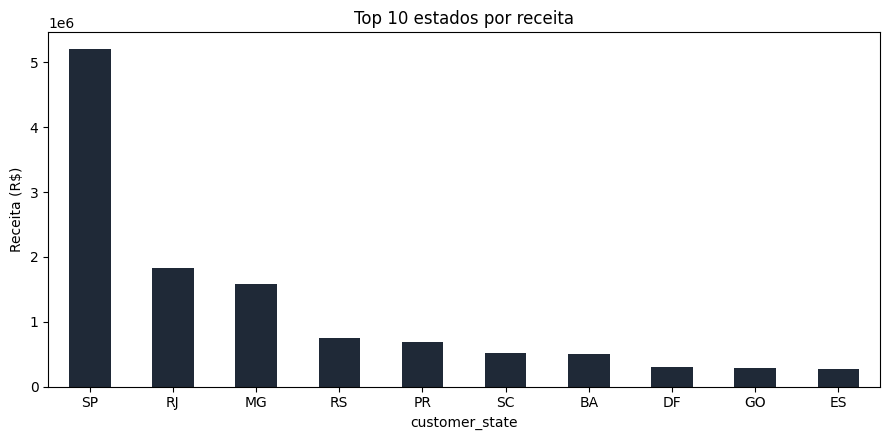

In [8]:
fig, ax = plt.subplots(figsize=(9, 4.5))
receita_estado.head(10).plot(kind="bar", ax=ax, color="#1f2937")
ax.set_title("Top 10 estados por receita")
ax.set_ylabel("Receita (R$)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### Estados com ticket médio alto

In [9]:
print("Top 10 estados por ticket médio:")
print(ticket_medio_estado.head(10).round(2))

Top 10 estados por ticket médio:
customer_state
PB    216.67
AP    198.15
AC    197.32
AL    195.41
RO    186.80
PA    184.48
TO    177.86
PI    176.30
MT    173.26
RN    172.27
dtype: float64


### Oportunidades: pouco volume, ticket médio alto

Estados abaixo da mediana de número de pedidos, mas acima da mediana de ticket médio — candidatos a explorar mais, já que o cliente que compra ali gasta bem, só tem pouco volume ainda.

In [10]:
resumo_estado = pd.DataFrame({"pedidos": pedidos_estado, "ticket_medio": ticket_medio_estado, "receita": receita_estado})
mediana_pedidos = resumo_estado["pedidos"].median()
mediana_ticket = resumo_estado["ticket_medio"].median()

oportunidades = resumo_estado[(resumo_estado["pedidos"] < mediana_pedidos) & (resumo_estado["ticket_medio"] > mediana_ticket)]
print(oportunidades.sort_values("ticket_medio", ascending=False).round(2))

                pedidos  ticket_medio    receita
customer_state                                  
PB                  532        216.67  115268.08
AP                   68        198.15   13474.30
AC                   81        197.32   15982.95
AL                  411        195.41   80314.81
RO                  247        186.80   46140.64
TO                  279        177.86   49621.74
PI                  493        176.30   86914.08
RN                  482        172.27   83034.98
SE                  345        170.79   58920.85
RR                   46        170.20    7829.43


## 3. Distribuição por Categoria

In [11]:
receita_categoria = fato.groupby("product_category_name_english")["price"].sum().sort_values(ascending=False)
print("Top 10 categorias por receita:")
print(receita_categoria.head(10).round(0))

Top 10 categorias por receita:
product_category_name_english
health_beauty            1258681.0
watches_gifts            1205006.0
bed_bath_table           1036989.0
sports_leisure            988049.0
computers_accessories     911954.0
furniture_decor           729762.0
cool_stuff                635291.0
housewares                632249.0
auto                      592720.0
garden_tools              485256.0
Name: price, dtype: float64


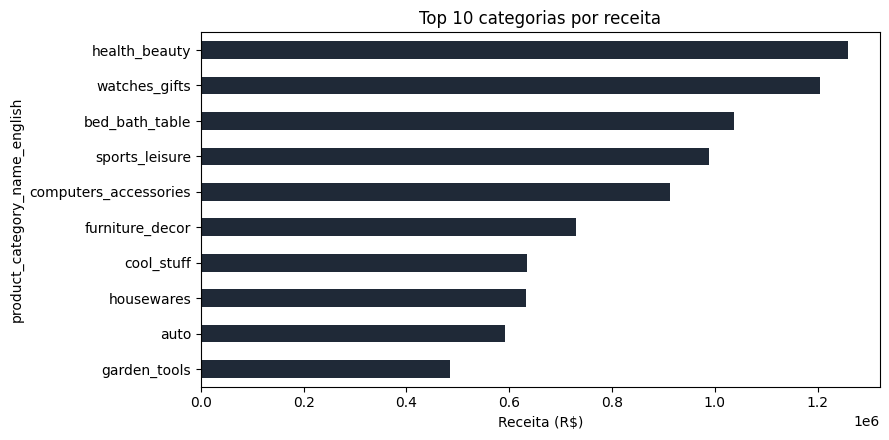

In [12]:
fig, ax = plt.subplots(figsize=(9, 4.5))
receita_categoria.head(10).plot(kind="barh", ax=ax, color="#1f2937")
ax.set_title("Top 10 categorias por receita")
ax.set_xlabel("Receita (R$)")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

### Ticket médio por categoria (top 10 por receita)

In [13]:
top10_categorias = receita_categoria.head(10).index
pedidos_categoria = fato[fato["product_category_name_english"].isin(top10_categorias)].groupby("product_category_name_english")["order_id"].nunique()
ticket_medio_categoria = (receita_categoria.loc[top10_categorias] / pedidos_categoria).sort_values(ascending=False)
print(ticket_medio_categoria.round(2))

product_category_name_english
watches_gifts            214.26
cool_stuff               174.91
auto                     152.10
health_beauty            142.45
garden_tools             137.94
computers_accessories    136.34
sports_leisure           127.99
furniture_decor          113.16
bed_bath_table           110.12
housewares               107.45
dtype: float64


### Categorias em crescimento vs. em queda

Comparando a primeira metade do período válido (jan/2017-out/2017) com a segunda metade (nov/2017-ago/2018), para as top 10 categorias por receita.

In [14]:
primeira_metade = meses_validos[meses_validos["ano_mes"] <= "2017-10"]
segunda_metade = meses_validos[meses_validos["ano_mes"] > "2017-10"]

receita_1a_metade = primeira_metade.groupby("product_category_name_english")["price"].sum()
receita_2a_metade = segunda_metade.groupby("product_category_name_english")["price"].sum()

crescimento_categoria = ((receita_2a_metade - receita_1a_metade) / receita_1a_metade * 100).loc[top10_categorias].sort_values(ascending=False)
print(crescimento_categoria.round(1))

product_category_name_english
watches_gifts            171.6
housewares               170.5
health_beauty            167.3
auto                     149.6
computers_accessories    109.1
sports_leisure           100.7
furniture_decor           99.2
bed_bath_table            89.1
garden_tools              47.9
cool_stuff                12.6
Name: price, dtype: float64


## 4. Performance de Sellers

In [15]:
receita_seller = fato_pedidos.groupby("seller_id")["price"].sum().sort_values(ascending=False)
print("Top 10 sellers por receita:")
print(receita_seller.head(10).round(0))

receita_total = fato_pedidos["price"].sum()
print(f"\nTop 10 sellers = {receita_seller.head(10).sum()/receita_total*100:.1f}% da receita, de {fato_pedidos['seller_id'].nunique()} sellers")

Top 10 sellers por receita:
seller_id
4869f7a5dfa277a7dca6462dcf3b52b2    229473.0
53243585a1d6dc2643021fd1853d8905    222776.0
4a3ca9315b744ce9f8e9374361493884    200473.0
fa1c13f2614d7b5c4749cbc52fecda94    194042.0
7c67e1448b00f6e969d365cea6b010ab    187924.0
7e93a43ef30c4f03f38b393420bc753a    176432.0
da8622b14eb17ae2831f4ac5b9dab84a    160237.0
7a67c85e85bb2ce8582c35f2203ad736    141746.0
1025f0e2d44d7041d6cf58b6550e0bfa    138969.0
955fee9216a65b617aa5c0531780ce60    135172.0
Name: price, dtype: float64

Top 10 sellers = 13.1% da receita, de 3095 sellers


### Concentração de receita entre sellers (curva de Pareto)

In [16]:
receita_seller_ordenada = receita_seller.sort_values(ascending=False)
receita_acumulada_pct = receita_seller_ordenada.cumsum() / receita_total * 100

print("% da receita concentrada nos top N sellers:")
for n in [10, 50, 100, 500]:
    print(f"  Top {n} sellers: {receita_acumulada_pct.iloc[n-1]:.1f}%")

% da receita concentrada nos top N sellers:
  Top 10 sellers: 13.1%
  Top 50 sellers: 32.9%
  Top 100 sellers: 45.1%
  Top 500 sellers: 78.2%


### Perfil dos sellers: alto volume x alto ticket médio

In [17]:
pedidos_seller = fato_pedidos.groupby("seller_id")["order_id"].nunique()
ticket_medio_seller = receita_seller / pedidos_seller

perfil_sellers = pd.DataFrame({"receita": receita_seller, "pedidos": pedidos_seller, "ticket_medio": ticket_medio_seller})
print("Top 5 sellers por volume de pedidos:")
print(perfil_sellers.sort_values("pedidos", ascending=False).head(5).round(2))

print("\nTop 5 sellers por ticket médio (com pelo menos 10 pedidos):")
print(perfil_sellers[perfil_sellers["pedidos"] >= 10].sort_values("ticket_medio", ascending=False).head(5).round(2))

Top 5 sellers por volume de pedidos:
                                    receita  pedidos  ticket_medio
seller_id                                                         
6560211a19b47992c3666cc44a7e94c0  123304.83     1854         66.51
4a3ca9315b744ce9f8e9374361493884  200472.92     1806        111.00
cc419e0650a3c5ba77189a1882b7556a  104288.42     1706         61.13
1f50f920176fa81dab994f9023523100  106939.21     1404         76.17
da8622b14eb17ae2831f4ac5b9dab84a  160236.57     1314        121.95

Top 5 sellers por ticket médio (com pelo menos 10 pedidos):
                                   receita  pedidos  ticket_medio
seller_id                                                        
59417c56835dd8e2e72f91f809cd4092  36459.00       18       2025.50
40db9e9aa57f7bb151bcda6b0f9bdbb7  23168.00       12       1930.67
2bf6a2c1e71bbd29a4ad64e6d3c3629f  50628.90       30       1687.63
c3acdfac4e3e97ff87529454fbc03642  16788.00       12       1399.00
b1b3948701c5c72445495bd161b83a4c  246

## 5. Recompra por Estado

In [18]:
recompra_estado = dim_clientes.groupby("customer_state").agg(
    pedidos=("customer_id", "nunique"),
    clientes_unicos=("customer_unique_id", "nunique"),
)
recompra_estado["taxa_recompra_pct"] = (1 - recompra_estado["clientes_unicos"] / recompra_estado["pedidos"]) * 100

print(recompra_estado.sort_values("taxa_recompra_pct", ascending=False).head(10).round(2))

                pedidos  clientes_unicos  taxa_recompra_pct
customer_state                                             
RO                  253              240               5.14
AC                   81               77               4.94
RJ                12852            12384               3.64
SP                41746            40302               3.46
RS                 5466             5277               3.46
MT                  907              876               3.42
ES                 2033             1964               3.39
AM                  148              143               3.38
GO                 2020             1952               3.37
MG                11635            11259               3.23


## 6. Cruzamento com a Trilha de Logística

Aqui a análise de Crescimento se conecta direto com a pergunta norteadora do projeto, usando a coluna `atrasado` que já vem calculada em `fato_pedidos`.

### As regiões que mais vendem também são as que mais atrasam?

In [19]:
pedidos_unicos = fato.drop_duplicates(subset="order_id")
atraso_por_estado = pedidos_unicos.groupby("customer_state")["atrasado"].mean() * 100

comparativo_estado = pd.DataFrame({
    "receita": receita_estado,
    "pct_atrasados": atraso_por_estado,
}).dropna().sort_values("receita", ascending=False)

print(comparativo_estado.head(10).round(2))

                   receita  pct_atrasados
customer_state                           
SP              5202955.05           5.77
RJ              1824092.67          13.04
MG              1585308.03           5.53
RS               750304.02           7.03
PR               683083.76           4.92
SC               520553.34           9.58
BA               511349.99          13.61
DF               302603.94           6.92
GO               294591.95           7.97
ES               275037.31          12.05


### Clientes que sofreram atraso recompram menos?

In [20]:
cliente_teve_atraso = pedidos_unicos.groupby("customer_unique_id")["atrasado"].any()
pedidos_por_cliente = pedidos_unicos.groupby("customer_unique_id")["order_id"].nunique()

comparativo_recompra = pd.DataFrame({"teve_atraso": cliente_teve_atraso, "pedidos": pedidos_por_cliente})
recompra_por_grupo = comparativo_recompra.groupby("teve_atraso")["pedidos"].mean()

print("Média de pedidos por cliente, com e sem atraso na jornada:")
print(recompra_por_grupo.round(3))

Média de pedidos por cliente, com e sem atraso na jornada:
teve_atraso
False    1.032
True     1.056
Name: pedidos, dtype: float64


O resultado é contra-intuitivo: clientes que já sofreram atraso têm em média **mais** pedidos (1,056) do que os que nunca sofreram (1,032) — o oposto da hipótese inicial. Isso provavelmente não significa que atraso incentiva recompra; é mais provável que seja viés de exposição: quem compra mais vezes tem estatisticamente mais chances de pegar pelo menos um pedido atrasado ao longo da jornada. Reforça o alerta de correlação x causalidade — não dá para afirmar que atraso reduz (ou aumenta) recompra só com esse cruzamento.

## Resumo dos Achados

- Receita cresce em média 14,2% ao mês no período, com novembro se destacando (possível efeito Black Friday, a confirmar)
- SP concentra 38,3% da receita, mas tem uma das menores taxas de atraso (5,8%) — RJ e BA têm receita relevante e atraso bem mais alto (13%+), sinalizando onde priorizar melhoria logística
- Estados como PB, AL e RO têm ticket médio alto e volume ainda baixo — candidatos a explorar mais
- Top 5 categorias somam 39,7% da receita — não há uma única categoria dominante isolada; watches_gifts tem o maior ticket médio e também cresceu mais entre as duas metades do período
- Receita bastante pulverizada entre sellers (top 10 = 13,1%, top 100 = 45,1%) — sem dependência excessiva de poucos vendedores
- Taxa de recompra geral de apenas 3,36% — ponto de atenção para qualquer estratégia de crescimento sustentável; RO e AC (baixo volume) têm as maiores taxas relativas
- O cruzamento direto entre "ter sofrido atraso" e "número de pedidos" não mostrou o padrão esperado — é preciso uma análise mais robusta (ex.: controlando por tempo de relacionamento) antes de afirmar qualquer relação causal

## Próximos Passos

- Levar esses achados para o Storytelling incorporar no relatório executivo
- Compartilhar o comparativo estado x atraso com a análise de Logística, para consolidar a recomendação conjunta (priorizar RJ e BA, não SP, para melhoria logística)